# Multi-Target Tutorial

This tutorial shows how to use `bluepebble` as a Stone Soup plugin for a multi-target passive-sonar problem. Compared with the single-target case, the main change is not the acoustic simulation interface itself, but the extra care needed in detection management, bearing ambiguity, and track association once several sources are active at once.

## Background

`bluepebble` extends Stone Soup with passive-sonar-specific modelling blocks: towed-array platforms, underwater propagation, source and ambient-noise models, beamforming, and passive-sonar detection. Stone Soup still provides the core tracking abstractions, including truth types, motion models, associators, initiators, and trackers.

## Key Concepts

- `TowedArrayPlatform` remains a Stone Soup-compatible platform, but adds the array geometry needed for passive-sonar simulation.
- Multi-target acoustic scenes are still represented with standard Stone Soup `GroundTruthPath` objects, each carrying `bluepebble` source metadata.
- `BroadbandPassiveSonarArraySimulator` scales from one source to many; you pass multiple truth paths and one shared set of acoustic-processing components.
- The main downstream change is in the tracker: multiple simultaneous detections require association logic such as JPDA rather than the simpler single-target PDA pattern.

## What You Will Build

In this notebook you will assemble the following plugin workflow:
- A manoeuvring `TowedArrayPlatform` built on top of Stone Soup platform abstractions
- Three target truth paths with acoustic metadata for broadband source generation
- A range-dependent `bluepebble` propagation model and shared ambient/source models
- A beamformed bearing-time record and passive-sonar detections from the simulator
- A Stone Soup multi-target bearing tracker driven by those detections


## Simulation Timing and Reproducibility

As in the single-target workflow, begin by defining one shared simulation clock. In `bluepebble`, the timestep is more than a plotting convenience: it controls platform propagation, the cadence of acoustic synthesis, and the update rate of the detection and tracking pipeline.

Keeping the timing configuration explicit also makes it easier to scale the same workflow to longer scenarios or denser target sets later on.


In [1]:
from datetime import datetime, timedelta

import numpy as np

# Random seed for reproducibility
seed = 2000
np.random.seed(seed)

# Simulation parameters
sim_duration = timedelta(seconds=900)
time_interval = timedelta(seconds=5)

num_steps = int(sim_duration.total_seconds() / time_interval.total_seconds())
start_time = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)
timesteps = [start_time + i * time_interval for i in range(num_steps)]

## Build a Manoeuvring `TowedArrayPlatform`

This section shows how the plugin reuses Stone Soup motion modelling for a more realistic host trajectory. The platform still starts from a Stone Soup `GroundTruthState` and uses standard transition models, but `TowedArrayPlatform` turns that motion into an evolving array geometry suitable for passive beamforming.

That distinction matters in multi-target scenes: array heading and curvature affect the separability of bearing tracks, so the platform model is not just bookkeeping. It directly influences what the beamformer and detector can resolve.


In [2]:
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    KnownTurnRate,
)
from stonesoup.types.groundtruth import GroundTruthState

from bluepebble.platform import TowedArrayPlatform

# Define the platform's initial state and transition model
platform_start_vector = np.array([-7500.0, 1.15, -2000.0, 0.25, -5.0, 0.0])
platform_position_mapping = [0, 2, 4]
platform_velocity_mapping = [1, 3, 5]
platform_turn_rate_radps = np.deg2rad(1.0)

leg1_duration_s = timedelta(seconds=405)
turn1_angle_rad = np.deg2rad(-45)
turn1_duration_s = timedelta(
    seconds=round((abs(turn1_angle_rad) / platform_turn_rate_radps) / 5.0) * 5.0
)
leg2_duration_s = sim_duration - leg1_duration_s - turn1_duration_s

straight_model = CombinedLinearGaussianTransitionModel(
    [ConstantVelocity(0.0), ConstantVelocity(0.0), ConstantVelocity(0.0)]
)

turn_rate_rad1 = np.sign(turn1_angle_rad) * platform_turn_rate_radps
planar_turn1 = KnownTurnRate(
    turn_rate=turn_rate_rad1,
    turn_noise_diff_coeffs=np.array([0.0, 0.0]),
)
depth_model = ConstantVelocity(0.0)
turning_model1 = CombinedLinearGaussianTransitionModel([planar_turn1, depth_model])

transition_models = [straight_model, turning_model1, straight_model]
transition_times = [leg1_duration_s, turn1_duration_s, leg2_duration_s]

# Define the towed array parameters
num_sensors = 200
tow_cable_length_m = 100.0
sensor_spacing_m = 0.5
array_depth_m = -50.0

# Create the towed array platform and simulate its movement over time
platform_initial_state = GroundTruthState(platform_start_vector, timestamp=start_time)
platform = TowedArrayPlatform(
    states=platform_initial_state,
    position_mapping=platform_position_mapping,
    velocity_mapping=platform_velocity_mapping,
    transition_models=transition_models,
    transition_times=transition_times,
    num_sensors=num_sensors,
    cable_length_m=tow_cable_length_m,
    sensor_spacing_m=sensor_spacing_m,
    array_depth_m=array_depth_m,
)

for timestamp in timesteps[1:]:
    platform.move(timestamp)

## Create Multiple Truth Paths with Acoustic Metadata

The targets are built with standard Stone Soup truth objects, but each truth state carries metadata describing the emitted acoustic source. This keeps the modelling split clean:
- State vectors describe where each target is and how it moves.
- Metadata describes what each target sounds like.

That separation is especially useful in multi-target work because you can vary kinematics and source content independently while still using the same simulator interface.


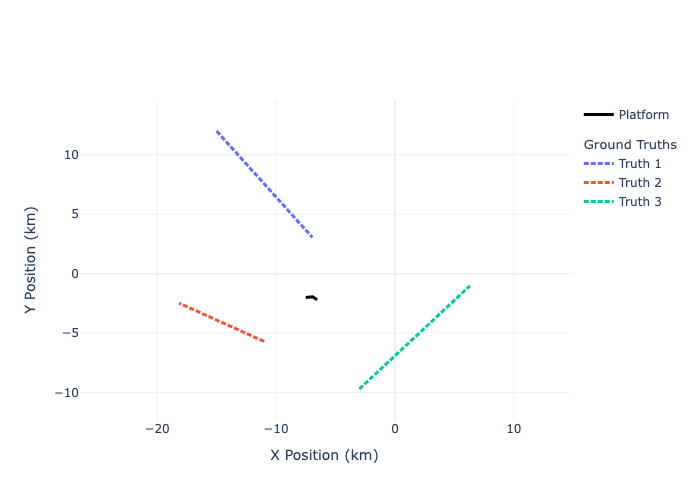

In [3]:
import numpy as np
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
)
from stonesoup.types.groundtruth import GroundTruthPath, GroundTruthState

from bluepebble.plotter import plot_world

# Define the target's initial state and transition model
target1_start_vector = np.array([-1.5e4, 9.0, 1.2e4, -10, -5.0, 0.0])
target2_start_vector = np.array([-1.1e4, -8.0, -5.7e3, 3.6, -5.0, 0.0])
target3_start_vector = np.array([-3.0e3, 10.4, -9.7e3, 9.7, -5.0, 0.0])

target_transition_model = CombinedLinearGaussianTransitionModel([
    ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)
])
target_position_mapping = [0, 2, 4]
target_velocity_mapping = [1, 3, 5]

target_truths = []

target_tonal_bandwidth_hz = np.random.uniform(0.5, 2.0)
target_noise_amplitude_upa = 10 ** (90 / 20)
target_noise_spectral_exponent = -1.0

for sv in [target1_start_vector, target2_start_vector, target3_start_vector]:
    metadata = {
        "position_mapping": target_position_mapping,
        "velocity_mapping": target_velocity_mapping,
        "amplitudes_upa": 10 ** (np.random.uniform(87, 102, 4) / 20),
        "frequencies_hz": np.random.uniform(50.0, 200.0, 4),
        "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
        "tonal_bandwidth_hz": np.random.uniform(0.5, 2.0),
        "noise_amplitude_upa": 10 ** (np.random.uniform(65, 85) / 20),
        "target_tonal_bandwidth_hz": target_tonal_bandwidth_hz,
        "target_noise_amplitude_upa": target_noise_amplitude_upa,
        "noise_spectral_exponent": target_noise_spectral_exponent,
    }
    target_states = [GroundTruthState(sv, timestamp=start_time, metadata=metadata)]
    for timestamp in timesteps[1:]:
        dt = timestamp - target_states[-1].timestamp
        new_state_vector = target_transition_model.function(
            target_states[-1], noise=False, time_interval=dt
        )
        target_states.append(
            GroundTruthState(new_state_vector, timestamp=timestamp, metadata=metadata)
        )

    target_truths.append(GroundTruthPath(target_states))

plot_world(truths=target_truths, platform=platform).show()

## Configure a `bluepebble` Propagation Model

The multi-target tutorial uses a more sophisticated propagation model than the single-target notebook. This highlights an important plugin usage point: the surrounding workflow does not change much when you swap acoustic fidelity.

Here the code configures `rtrsAcousticPropagationModel` together with a sound-speed profile and bathymetry. From the perspective of the simulator, it is simply another propagation component that maps source/platform geometry into array-level acoustic arrivals.


In [4]:
from bluepebble.models.environment import FlatBathymetry, Linear
from bluepebble.models.propagation import rtrsAcousticPropagationModel

ssp = Linear(surface_speed=1500.0, gradient=0.2)
bathymetry = FlatBathymetry(depth=-150.0)
attenuation_factor = 0.5

propagation_model = rtrsAcousticPropagationModel(
    ssp=ssp,
    bathymetry=bathymetry,
    use_all_frequencies=False,
    step_m=20.0,
    azimuth_search_width=2.0,
    azimuth_resolution=0.5,
    elevation_range=(-25.0, 25.0),
    elevation_resolution=1.0,
)

## Configure Shared Source and Noise Models

Next, define the signal models that will be reused across the target set. `bluepebble` lets you keep one consistent processing configuration while still simulating several independent sources.

The tutorial uses `ColouredNoise` for ambient background and `BroadbandSyntheticSignal` for target emissions. In this setup, the source model is shared across targets and reads the per-target metadata attached in the truth-generation step. This is the usual plugin pattern when several targets should be processed with the same acoustic assumptions.


In [5]:
from bluepebble.signal.ambient import ColouredNoise
from bluepebble.signal.anthropogenic import BroadbandSyntheticSignal

sampling_rate_hz = 500.0
frame_len = 500
hop_factor = 2
duration_s = num_steps * time_interval.total_seconds()

ambient_amplitude_upa = 10 ** (45 / 20)
ambient_spectral_exponent = -1
ambient_noise_model = ColouredNoise(
    amplitude_upa=ambient_amplitude_upa,
    spectral_exponent=ambient_spectral_exponent,
    duration_s=time_interval.total_seconds(),
    sampling_rate_hz=sampling_rate_hz,
)

signal_model = BroadbandSyntheticSignal(
    duration_s=duration_s,
    sampling_rate_hz=sampling_rate_hz,
    frame_len=frame_len,
    hop_factor=hop_factor,
    tonal_bandwidth_hz=target_tonal_bandwidth_hz,
    noise_amplitude_upa=target_noise_amplitude_upa,
    noise_spectral_exponent=target_noise_spectral_exponent,
    noise_freq_range_hz=(0.0, sampling_rate_hz / 2),
    tonal_noise_is_constant=True,
    noise_is_constant=True,
)

## Run Beamforming and Passive-Sonar Detection

This is the main acoustic-processing stage. `BroadbandPassiveSonarArraySimulator` consumes the platform, propagation model, truth paths, source models, and steering calculator to produce beamformed output over time.

`PassiveSonarDetector` then turns that output into discrete detections using a sonar-specific chain of thresholding and peak selection. In multi-target scenes, this stage is where overlapping bearing structure, sidelobes, and clutter begin to influence the tracking problem downstream.


In [6]:
import numpy as np

from bluepebble.detector import CACFARDetector, PassiveSonarDetector, PeakDetector
from bluepebble.plotter import plot_btr
from bluepebble.sigproc import (
    DelayAndSumBeamformer,
    SteeringCalculator,
)
from bluepebble.simulator import BroadbandPassiveSonarArraySimulator

steering_azimuths_rad = np.linspace(-np.pi, np.pi, 361)

beamformer = DelayAndSumBeamformer(
    sampling_rate_hz=sampling_rate_hz,
    shading=None,
    domain="frequency",
)

steering_calculator = SteeringCalculator(
    ssp=ssp,
    steering_azimuths_rad=steering_azimuths_rad,
)

fade_in_ms = 1000.0

simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=propagation_model,
    signal_models=[signal_model],
    noise_model=ambient_noise_model,
    beamformer=beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=target_truths,
    fade_in_ms=fade_in_ms,
)

cfar_detector = CACFARDetector(
    num_guard_cells=6,
    num_training_cells=10,
    threshold_factor=1.05,
    mode="wrap"
)
peak_detector = PeakDetector(distance=8)

detection_chain = [cfar_detector, peak_detector]

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=simulator.sensor_data_gen(),
    steering_azimuths_rad=steering_azimuths_rad,
)

all_detections = list(detector.detections_gen(progress_bar=True))
snr_map = detector.snr_history

detections_for_plotter = [d for _, detections in all_detections for d in detections]

print(f"Total no. of detections: {len(detections_for_plotter)}")

Generating Detections: 0it [00:00, ?it/s]

Generating Detections: 1it [00:37, 37.72s/it]

Generating Detections: 2it [00:38, 15.74s/it]

Generating Detections: 3it [00:38,  8.71s/it]

Generating Detections: 4it [00:38,  5.41s/it]

...

Generating Detections: 178it [01:48,  2.54it/s]

Generating Detections: 179it [01:48,  2.56it/s]

Generating Detections: 180it [01:48,  2.56it/s]

Generating Detections: 180it [01:48,  1.65it/s]

Total no. of detections: 986


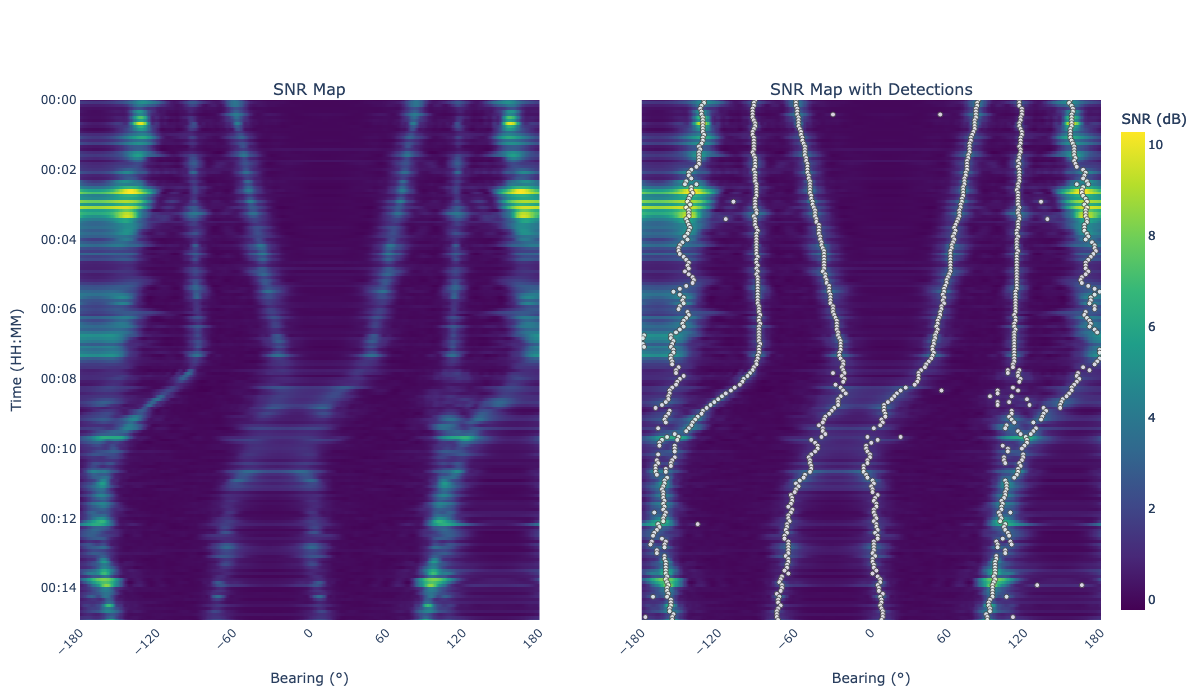

In [7]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2, shared_yaxes=True, subplot_titles=("SNR Map", "SNR Map with Detections")
)

plot_btr(
    data=snr_map,
    timesteps=timesteps,
    steering_azimuths=np.rad2deg(steering_azimuths_rad),
    fig=fig, row=1, col=1
)
plot_btr(
    data=snr_map,
    detections=detections_for_plotter,
    timesteps=timesteps,
    steering_azimuths=np.rad2deg(steering_azimuths_rad),
    fig=fig, row=1, col=2
)

fig.update_layout(width=1200, height=700, yaxis2=dict(title=""))
fig.show()

## Track Multiple Bearings with Stone Soup Association

Once detections exist, the workflow hands back to Stone Soup. The `bluepebble` portion of the pipeline has already converted the acoustic scene into bearing detections; Stone Soup now handles track initiation, data association, state estimation, and deletion.

The main difference from the single-target tutorial is association complexity. With several simultaneous sources, the tracker must reason about competing explanations for each scan, so the notebook uses JPDA and a multi-measurement initiator rather than a simpler single-track setup.

We again convert Cartesian truth to relative-bearing truth so detections, truths, and tracks can be inspected on the same bearing-time axes.


In [8]:
relative_bearing_truths = []

for target_truth in target_truths:
    bearing_states = []
    for state in target_truth:
        platform_state = platform.get_platform_state_at(state.timestamp)
        ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)

        target_xy = np.array([state.state_vector[0], state.state_vector[2]])
        relative_position = target_xy - ref_sensor_position[:2]
        bearing = np.arctan2(relative_position[1], relative_position[0])

        bearing_states.append(
            GroundTruthState(np.array([bearing]), timestamp=state.timestamp)
        )

    relative_bearing_truths.append(GroundTruthPath(bearing_states))

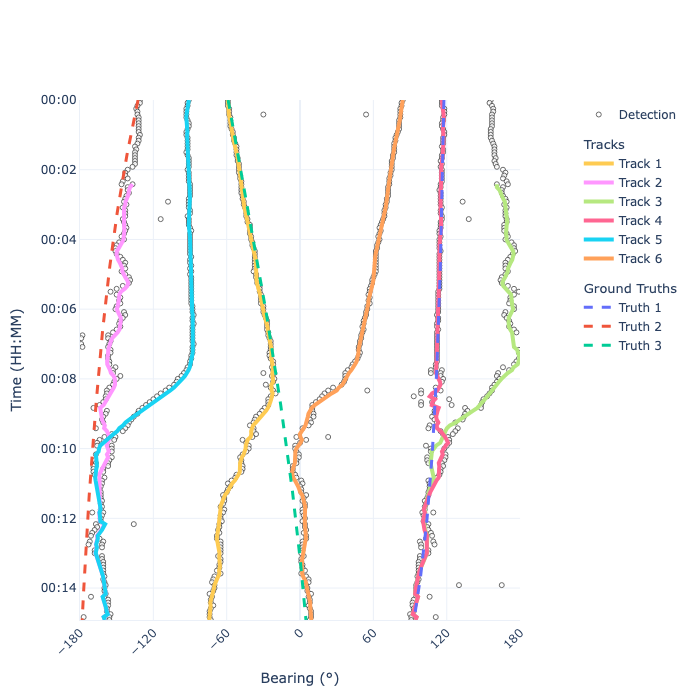

In [9]:
import numpy as np
from stonesoup.dataassociator.neighbour import GNNWith2DAssignment
from stonesoup.dataassociator.probability import JPDA
from stonesoup.deleter.error import CovarianceBasedDeleter
from stonesoup.functions import mod_bearing
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.measures import Mahalanobis
from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.models.transition.linear import ConstantVelocity
from stonesoup.predictor.kalman import KalmanPredictor
from stonesoup.tracker.simple import MultiTargetMixtureTracker
from stonesoup.types.state import GaussianState
from stonesoup.updater.kalman import KalmanUpdater

from bluepebble.plotter import plot_btr

transition_model = ConstantVelocity(0.000001)

predictor = KalmanPredictor(transition_model)

measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(12) ** 2]]),
)

updater = KalmanUpdater(measurement_model=measurement_model)

fov_rad = np.deg2rad(360)
expected_false_alarms_per_scan = 3
clutter_spatial_density = expected_false_alarms_per_scan / fov_rad

hypothesiser = PDAHypothesiser(
    predictor=predictor,
    updater=updater,
    clutter_spatial_density=clutter_spatial_density,
    prob_detect=0.85,
)
data_associator = JPDA(hypothesiser=hypothesiser)

init_hypothesiser = DistanceHypothesiser(
    predictor=predictor,
    updater=updater,
    measure=Mahalanobis(),
    missed_distance=6,
)
init_associator = GNNWith2DAssignment(init_hypothesiser)

deleter = CovarianceBasedDeleter(covar_trace_thresh=0.2)

# Get bearing from first detection for prior state
first_detection = next(
    det
    for _, det_set in all_detections
    if det_set
    for det in det_set
)

initial_bearing = float(first_detection.state_vector[0, 0])

prior_state = GaussianState(
    np.array([[first_detection], [0.0]]),
    np.diag([np.deg2rad(5) ** 2, np.deg2rad(0.5) ** 2]),
    timestamp=start_time,
)

initiator = MultiMeasurementInitiator(
    prior_state=prior_state,
    measurement_model=measurement_model,
    deleter=deleter,
    data_associator=init_associator,
    updater=updater,
    min_points=60,
)

kf = MultiTargetMixtureTracker(
    initiator=initiator,
    deleter=deleter,
    detector=all_detections,
    data_associator=data_associator,
    updater=updater,
)

tracks = set()

for _, current_tracks in kf:
    for track in current_tracks:
        track[-1].state_vector[0, 0] = mod_bearing(float(track[-1].state_vector[0, 0]))
    tracks |= current_tracks

plot_btr(
    timesteps=timesteps,
    steering_azimuths=np.rad2deg(steering_azimuths_rad),
    truths=relative_bearing_truths,
    detections=detections_for_plotter,
    tracks=tracks,
    figsize=(700, 700),
).show()

## Adapting This Tutorial

The multi-target plugin workflow is the same basic pattern as the single-target case, but with more emphasis on separability and association:
1. Build Stone Soup truth and platform objects.
2. Add `bluepebble` array geometry, propagation, and acoustic source/noise models.
3. Simulate beamformed output and generate passive-sonar detections.
4. Use Stone Soup association and tracking logic to maintain multiple bearing tracks.
